In [1]:
import math

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from pandas import Series
from sklearn.preprocessing import LabelEncoder

In [2]:
# 加载数据
yale = loadmat('data_aug.mat')

X = yale['data']
y = yale['labels'].T.flatten()     #将数据展开

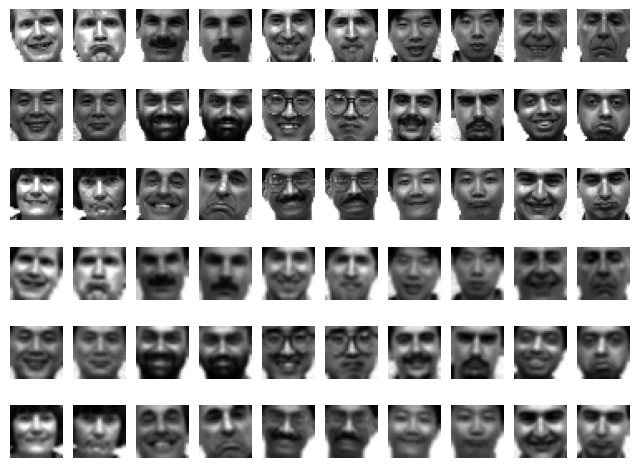

In [3]:
# 可视化
data = X
num = len(X)

plt.figure(dpi=100, figsize=(8, 6))

for i in range(num):
    data = X[i].reshape((32, 32)).T
    plt.subplot(6, 10, i + 1)
    plt.axis('off')
    plt.imshow(data, cmap='gray')
# plt.savefig("figures/yale.pdf")
plt.show()


In [4]:
from sklearn.model_selection import train_test_split
# 分割数据集
X_train, X_test, y_train, y_test = train_test_split(X, y)
len(X_train)

45

In [5]:
# 分组
matrix = np.arange(1024).reshape((32, 32))
n = 8    # 矩阵每行分成几份
Groups = []
m1 = np.split(matrix, n, axis=0)
for m in m1:
    group = np.split(m, n, axis=1)
    Groups = Groups + group

for i in range(len(Groups)):
    Groups[i] = Groups[i].flatten()
len(Groups)

64

In [6]:
import sys
sys.path.append("..")
from SGLN import LassoNetClassifier
# 模型训练
model = LassoNetClassifier(M=30, verbose=2, alpha=0.5, path_multiplier=1.05, lambda_start=0.2)
path = model.path(X_train, y_train,Groups=Groups)

Initialized dense model
1000 epochs, val_objective 1.19e-01, val_loss 1.19e-01, regularization 0.00e+00, l2_regularization 1.79e+00
-------------------------- 1 --------------------------
Lambda_ = 0.20, selected 1024 features 
100 epochs, val_objective 2.51e+00, val_loss 1.32e-01, regularization 2.38e+00, l2_regularization 1.79e+00
-------------------------- 2 --------------------------
Lambda_ = 0.21, selected 1024 features 
100 epochs, val_objective 1.36e+00, val_loss 1.14e-01, regularization 1.25e+00, l2_regularization 1.80e+00
-------------------------- 3 --------------------------
Lambda_ = 0.22, selected 1024 features 
100 epochs, val_objective 8.16e-01, val_loss 1.14e-01, regularization 7.02e-01, l2_regularization 1.80e+00
-------------------------- 4 --------------------------
Lambda_ = 0.23, selected 1024 features 
100 epochs, val_objective 6.81e-01, val_loss 1.17e-01, regularization 5.63e-01, l2_regularization 1.81e+00
-------------------------- 5 --------------------------


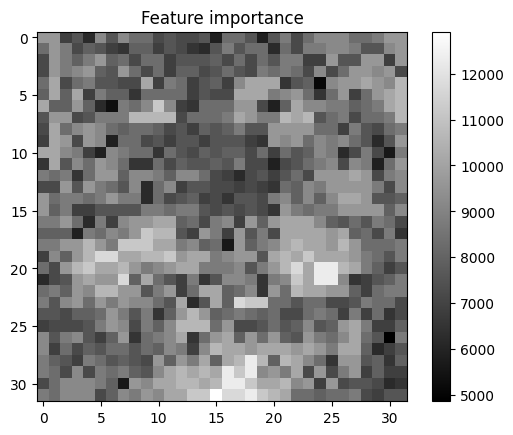

In [7]:
# 输出特征的重要性
img = model.feature_importances_.reshape(32, 32).T

plt.title("Feature importance")
plt.imshow(img, cmap='gray')
plt.colorbar()
plt.show()

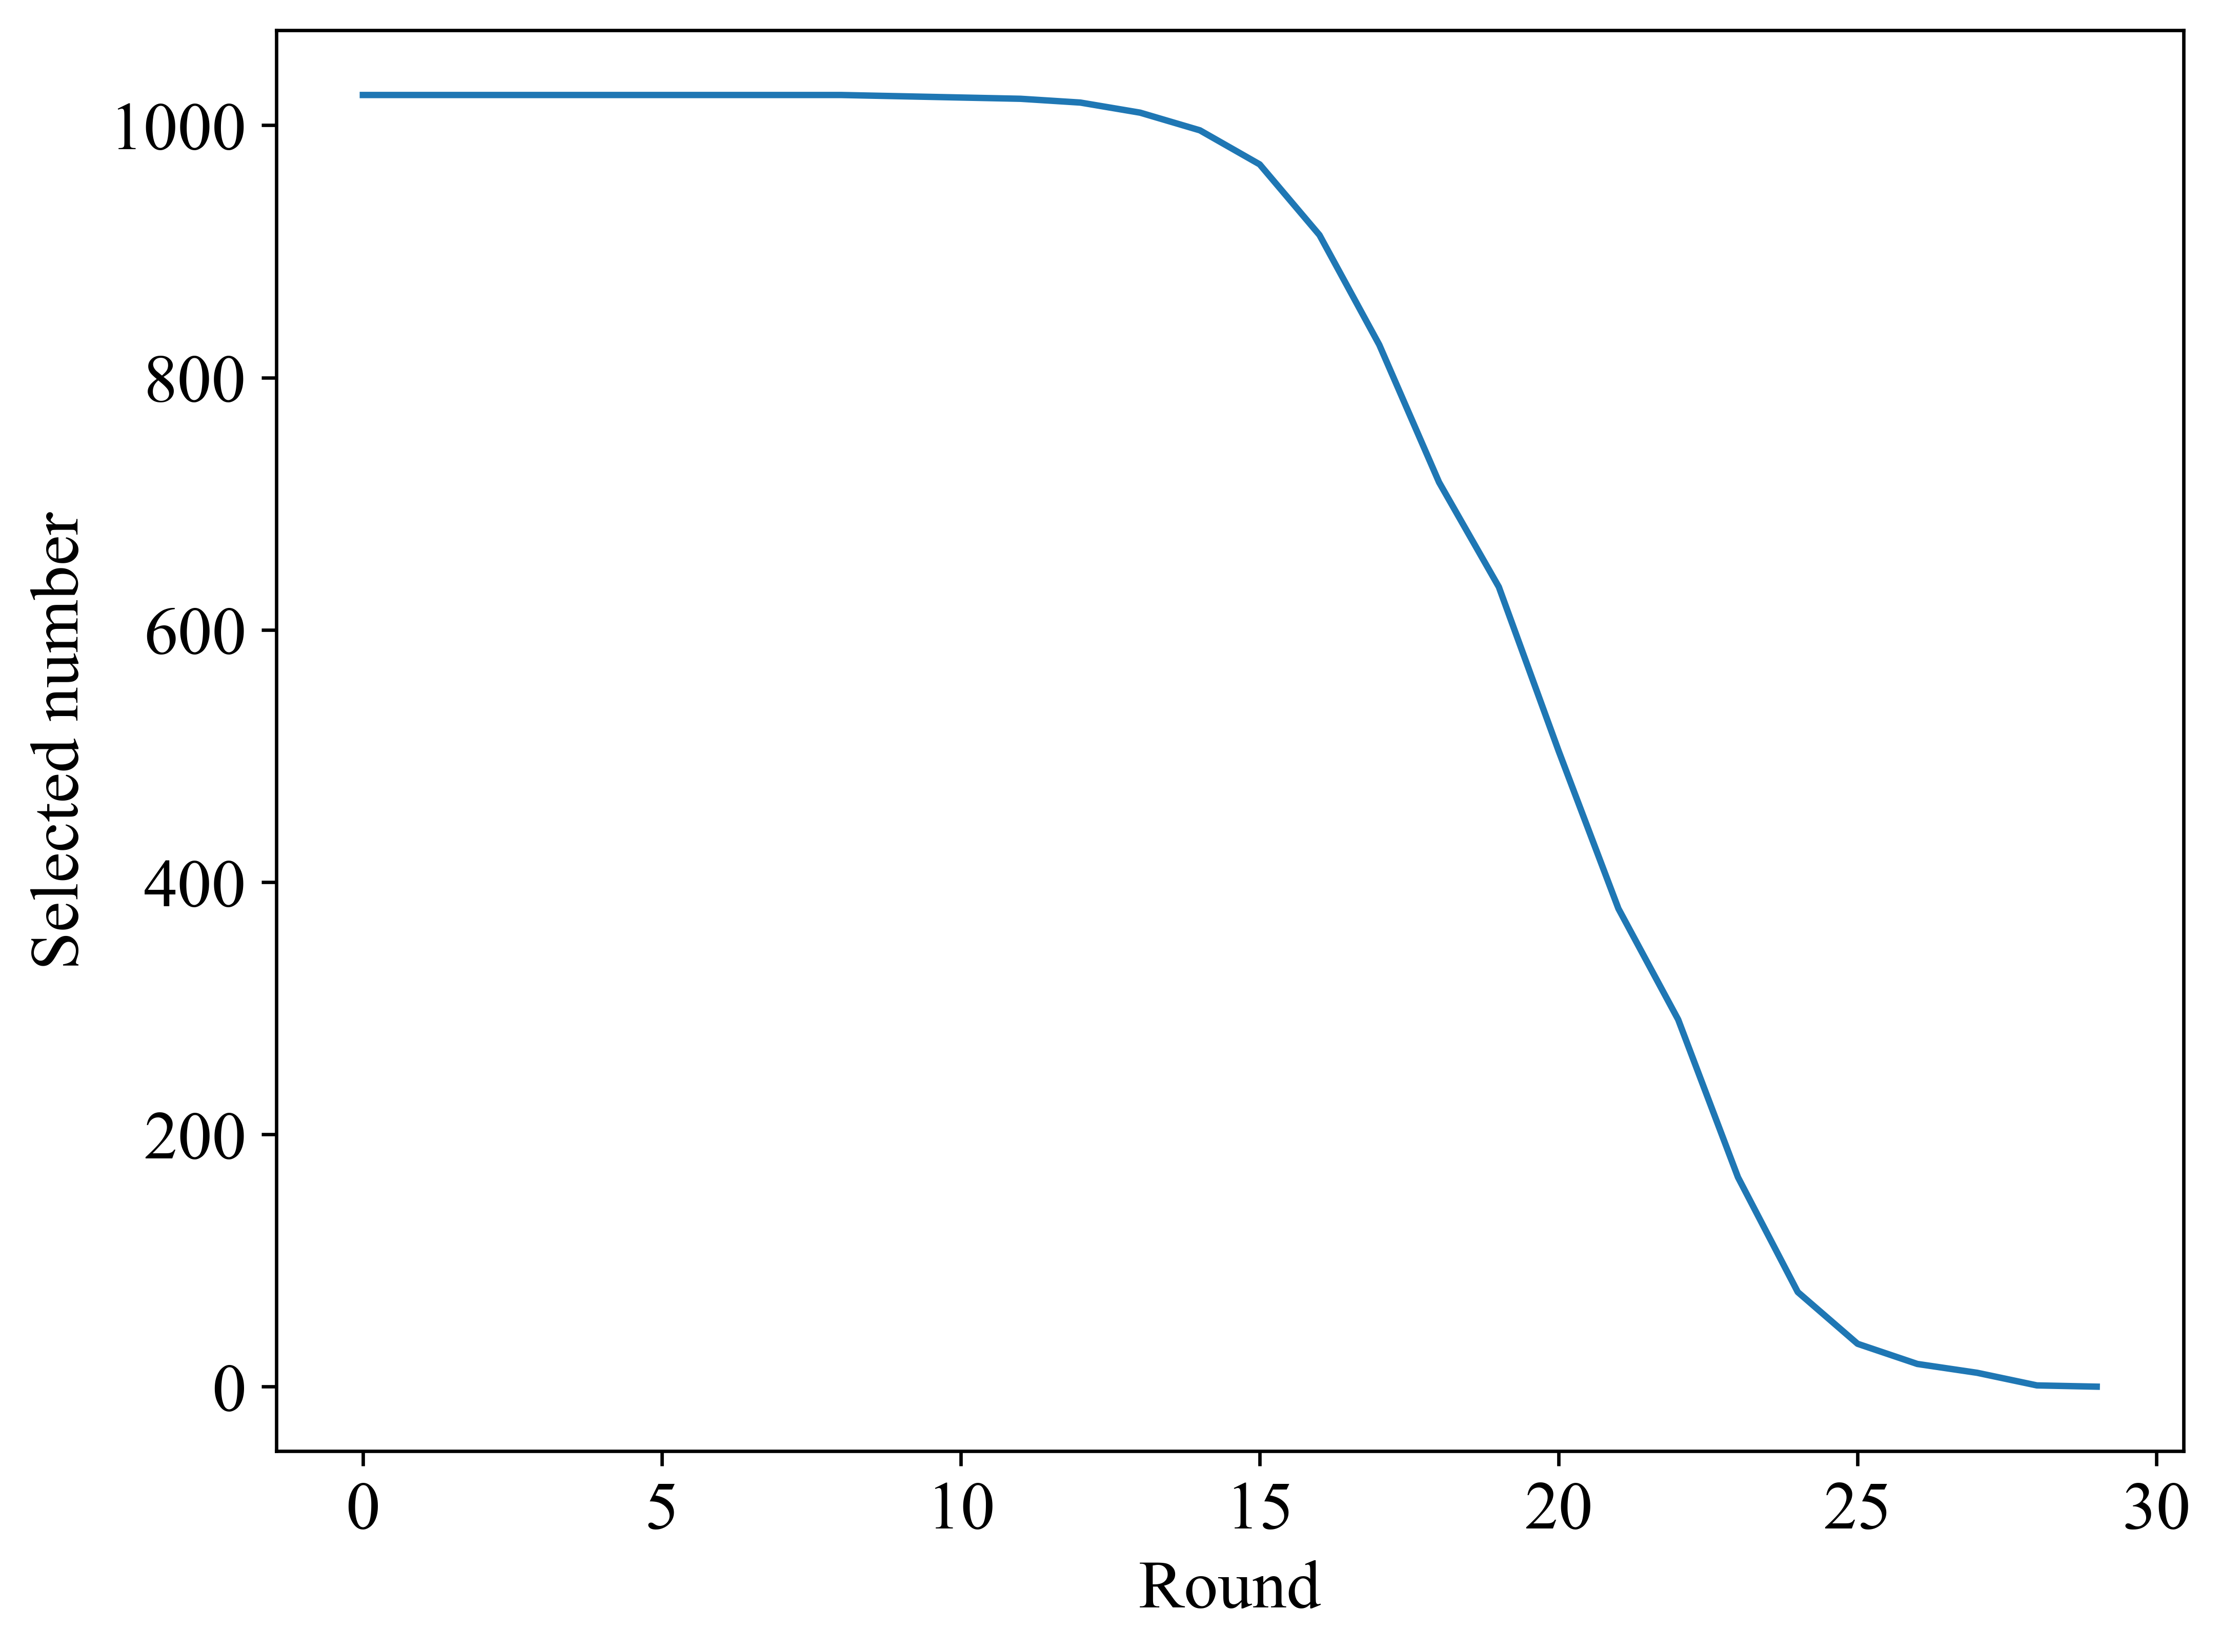

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
%matplotlib inline
config = {
    "font.family": 'Times New Roman',
    "font.size": 16,
}
rcParams.update(config)
plt.figure(dpi=600, figsize=(8, 6))
num = [int(sum(path_i.selected)) for path_i in path][-30:]
x_axis_data = [i for i in range(len(num))]
plt.plot(x_axis_data, num)
plt.xlabel("Round")
plt.ylabel("Selected number")
plt.savefig("figures/yale_selected_rounds.pdf")
plt.show()


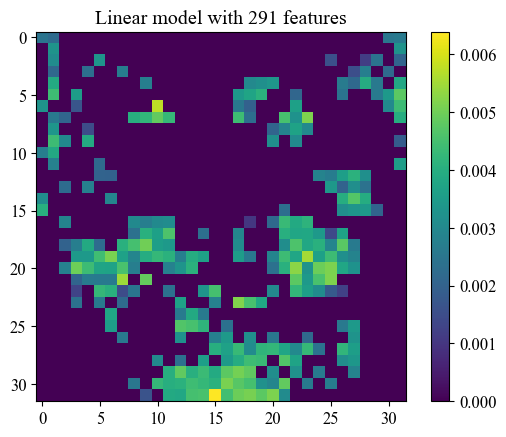

In [9]:
import torch
from matplotlib import rcParams
index = -8
weight = path[index].state_dict["skip.weight"]
importances = torch.norm(weight, p=2, dim=0) / torch.sum(torch.norm(weight, p=2, dim=0))

num = sum(path[index].selected)

config = {
    "font.family": 'Times New Roman',
    "font.size": 12
}
rcParams.update(config)
plt.clf()
plt.title(f"Linear model with {num} features")

img = (importances).reshape(32, 32).T
plt.imshow(img)
plt.colorbar()
plt.savefig("figures/yale_SGLN_selected.pdf", bbox_inches='tight')
plt.show()

In [10]:
# from sklearn.metrics import accuracy_score
# n_selected = []
# accuracy = []
# lambda_ = []

# for save in path:
#     model.load(save.state_dict)
#     y_pred = model.predict(X_test)
#     n_selected.append(save.selected.sum())
#     accuracy.append(accuracy_score(y_test, y_pred))
#     lambda_.append(save.lambda_)
# fig = plt.figure(figsize=(12, 6))

# plt.grid(True)
# plt.plot(accuracy, ".-")
# plt.xlabel("Round")
# plt.ylabel("classification accuracy")